# Supervised Finetuning of TL;DR post to GenZ summarizations 
This project's goal is about creating supervised finetuning of TL;DR prompts into GenZ summarization. This notebook is has multiple sections: 

* Analysis 
  * Analysis of GenZ Data
  * Generation of GenZ data utilising LLM
  * Data analysis of combinded GenZ
  * Analysis of TL;DR
  * Generation of TL;DR GenZ summarization by using the GenZ dataset and LLM
  * Data analysis of GenZ summarization in TL;DR
* Project
  * 
* Evaluation 

Dependencies loades

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
from itertools import chain
from regex import regex as re

from kagglehub import KaggleDatasetAdapter
from typing import Dict
from datasets import load_dataset, DownloadMode
from tqdm import tqdm

from scripts.libs.llm_client import LLMClient
from scripts.libs.analyse_slang_dataset import SlangAnalyzer
# Add progress bar integration
tqdm.pandas();

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
19033.96s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Use the function we have defined in our libary

In [35]:
client = LLMClient()
analyser = SlangAnalyzer()
basepath = "Data/"
gen_zz_words = "gen_zz_words.csv"
genz_slang_pairs = "genz-slang-pairs-1k.csv"
genz_slang = "genz_slang.csv"

# Data analysis
In this section we perform data analysis on GenZ datasets and on TL;DR dataset. The insights obtained justify the creation of synthetic data for both dataset. 

## Analysis of GenZ Data

### Data analysis for MLBtrio
We will start with analysing the MLBtrio dataset. As we can observe we have the columns: `Slang`, `Description`, `Example` and `Context` in the MLBtrio. This dataset gives us a understanding on how to use the slang, however it does not give us a representation how the sentence would be without slang. Here we have utilises the dataset loader from HuggingFace and shown the first 5 column. 

In [23]:
# Load the Gen Z slang dataset
dataset = load_dataset("MLBtrio/genz-slang-dataset", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)
df_mlbtrio = pd.DataFrame(dataset['train'])
df_mlbtrio.head(5)

Generating train split: 100%|██████████| 1779/1779 [00:00<00:00, 30136.22 examples/s]


,Slang,Description,Example,Context
0,W,Shorthand for win,"Got the job today, big W!",Typically used in conversations to celebrate s...
1,L,Shorthand for loss/losing,"I forgot my wallet at home, that’s an L.",Often used when referring to a failure or mish...
2,L+ratio,Response to a comment or action on the interne...,Your tweet got 5 likes and 100 replies calling...,Popularized on social media platforms to signi...
3,Dank,excellent or of very high quality,That meme is so dank!,Commonly used in internet slang to refer to me...
4,Cheugy,Derogatory term for Millennials. Used when mil...,"That phrase is so cheugy, no one says that any...",Used to refer to things that were once popular...


In [27]:
# Analyze all three datasets
analysis_mlbtrio : Dict = analyser.analyze(
    df_mlbtrio,
    column='Slang',
    dataset_name='MLBtrio/genz-slang-dataset'
)
analyser.show_total_statistics(analysis_mlbtrio)
analyser.show_duplication_analysis(analysis_mlbtrio)


DATASET ANALYSIS: MLBtrio/genz-slang-dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"1,779"
1,Unique (Case-Sensitive),"1,605"
2,Unique (Lowercase),"1,588"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),10.7%
1,Most Common Term,'af'
2,Most Common Count,4
3,Original Cases,"['Af', 'AF']"


As you can see the MLBtrui has `1,779` total amount of rows, whereas some of them are duplicates. As you can see the term `gg` or `GG` are duplicates and we have 4 of them in our slang column. We are using a function to simplify the amount of code for show the total statictis and duplication, since it would take up a lot of repetition.

### Data analysis for Programmer-RD-AI for genz-slang

Now we will analysing the Programmer-RD-AI dataset. As we can observe we have the columns: `normal` and `gen_z`. This dataset only has the representation of a text example in normal text and one in slang. However, it does not contain any column with the slang word or description or context it is used in. 

In [30]:
# Load the Programmer-RD-AI genz-slang-pairs-1k dataset
# Note: If you already have the data then load the data locally instead where there is already generated Slang columns and more. Skip to the later parts of the Notebook

df_pairs = pd.DataFrame()

if os.path.exists(basepath + genz_slang_pairs):
    df_pairs = pd.read_csv(basepath + genz_slang_pairs)
else:
    dataset_pairs = load_dataset("Programmer-RD-AI/genz-slang-pairs-1k", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)
    df_pairs = pd.DataFrame(dataset_pairs['train'])

In [ ]:
df_pairs = pd.DataFrame(dataset_pairs['train'])
df_pairs.head(5)

NameError: name 'dataset_pairs' is not defined

Since the data is built completely differently, whereas this exists of normal and GenZ slang. We would like to produces this into the same format with the Slang, Description, Example and the generated formal and informal text form earlier.


##### Extract the terms from the gen_z column
Use the LLM in the same way to create the term

In [6]:
prompt_extract = """You are a language refinement expert. You are extracting the slang term from the sentence.

Requirements:
- Provide ONLY the slang term with no explanations, quotes, or parentheses. It is only allowed to give me slang word in the sentence.
- Output only UTF-8 text characters (no emojis or special symbols)
- Do not include any meta-commentary about the task
- Do not include any meta-commentary about the word

Original text: {gen_z}

Rewritten version:"""

df_pairs = client.batch_process(
    df_pairs,
    prompt_template=prompt_extract,
    output_column="Slang"
)

In [10]:
df_pairs.head(5)

,normal,gen_z,Slang
0,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ...",z's
1,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h...",drained
2,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.,hype
3,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff...",caffeine
4,I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu...","hyped, turned up"


In [ ]:
df_pairs.to_csv(genz_slang_pairs, index=False)

In [116]:
# Reorder the columns and rename them so they align more with MLBtrio dataset

df_pairs = df_pairs[['Slang', 'gen_z', 'normal']].rename(columns={
    'normal': 'Informal_Text_Without_Slang',
    'gen_z': 'Example',
    'Slang': 'Slang'
})

# Save it to it own dataset
df_pairs.to_csv(basepath + genz_slang_pairs, index=False)
df_pairs

,Slang,Informal_Text_Without_Slang,Example
0,z's,"I'm really tired today, I think I need some rest.","I'm totally drained today, need to catch some ..."
1,drained,"I'm really tired today, I just want to relax a...","I'm hella drained today, just wanna chill at h..."
2,hype,I'm really excited for the concert tonight.,I'm so hype for the concert tonight.
3,caffeine,"I'm really tired today, I think I need some co...","I'm so drained today, I gotta get me some caff..."
4,"hyped, turned up",I'm really looking forward to the weekend.,"I'm so hyped for the weekend, can't wait to tu..."
...,...,...,...
1000,"dip, Z's",I think I should probably get some sleep now.,"Lowkey, I gotta dip and catch some Z's soon."
1001,sick,"Hey, did you see my new phone? It's pretty cool.","Yo, did you peep my new phone? It's mad sick."
1002,sesh,"Hey, do you want to grab dinner after work?","Yo, wanna hit up a dinner sesh after work?"
1003,hit,"Hey, do you want to go grab some coffee after ...","Yo, wanna hit up coffee after work? ✨"


As we can see in the Slang index 4 or 1000, there is multiple words in each the same column just spilt by a comma. So we want to create a new list of every term, so that we can analyse how many different terms there is in the dataset.

In [34]:
# Split each row when a comma comes and have a new list
def split_by_comma(line):
    """Split line by comma, remove parentheses content, and clean up"""
    if pd.isna(line):
        return []

    line = str(line)
    # Remove content within parentheses (including the parentheses)
    line = re.sub(r'\([^)]*\)', '', line)

    # Split by comma
    terms = line.split(',')

    # Clean up each term: strip whitespace, remove quotes, and convert to lowercase
    cleaned_terms = []
    for term in terms:
        term = term.strip()
        # Remove surrounding quotes (both single and double)
        term = term.strip('"\'')
        term = term.lower()
        if term:
            cleaned_terms.append(term)

    return cleaned_terms


Now we apply the funciton and we get a list of word that exist in the

In [35]:
slang_lists = df_pairs.Slang.apply(split_by_comma)

# Set into dataframe to be able to analyse the data
df_slang_set = pd.DataFrame(slang_lists)

analysis_pairs : Dict = analyser.analyze(
    df_slang_set,
    column='Slang',
    dataset_name='Programmer-RD-AI/genz-slang-pairs-1k'
)
analyser.show_total_statistics(analysis_pairs)
analyser.show_duplication_analysis(analysis_pairs)

TypeError: unhashable type: 'list'

### Looking into data set from Tawfia Yeasmin at Kaggle called Gen Z words and Phrases Dataset


In [48]:
# Load the latest version
hf_dataset = kagglehub.dataset_load(
  KaggleDatasetAdapter.HUGGING_FACE,
  "tawfiayeasmin/gen-z-words-and-phrases-dataset",
  gen_zz_words,
)

df_kaggle = pd.DataFrame(hf_dataset)

df_kaggle.head(5)


,Word/Phrase,Definition,Example Sentence,Popularity/Trend Level
0,Bop,A song that's really good.,"""That new track is a bop.""",Medium
1,Bounce,To leave or exit.,"""I'm bouncing, see you later.""",Medium
2,Cancelled,Publicly denounced and rejected.,"""She got cancelled after that post.""",High
3,Chill,Relaxed or easy-going.,"""I'm just chilling today.""",High
4,Cringe,Embarrassing or awkward.,"""That video was cringe.""",High


In [50]:
df_kaggle.columns = df_kaggle.columns.str.strip()
df_kaggle = df_kaggle[['Word/Phrase', 'Example Sentence', 'Definition', 'Popularity/Trend Level']].rename(columns={
    'Word/Phrase': 'Slang',
    'Example Sentence': 'Example',
    'Definition': 'Description',
    'Popularity/Trend Level': 'Popularity'
})

df_kaggle['Example'] = df_kaggle['Example'].str.strip('"\'')

df_kaggle.to_csv(basepath + gen_zz_words, index=False)

In [51]:
analysis_kaggle : Dict = analyser.analyze(
    df_kaggle,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_kaggle)
analyser.show_duplication_analysis(analysis_kaggle)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,204
1,Unique (Case-Sensitive),90
2,Unique (Lowercase),89


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),56.4%
1,Most Common Term,'drip'
2,Most Common Count,5
3,Original Cases,['Drip']


# Comparison of how many slang term in each of the data set is duplicated

Total unique slang terms in slang_kaggle: 89
SLANG DICTIONARY COMPARISON - THREE DATASETS

Dataset Sizes:
  MLBtrio/genz-slang-dataset: 1,588 unique terms
  Programmer-RD-AI/genz-slang-pairs-1k: 211 unique terms
  Gen Z Words and Phrases Dataset: 89 unique terms

Pairwise Overlaps:
  MLBtrio vs Pairs: 18 shared (1.13% of MLBtrio)
  MLBtrio vs Kaggle: 43 shared (2.71% of MLBtrio)
  Pairs vs Kaggle: 23 shared (10.90% of Pairs)

Triple Intersection (in all three): 11 terms

Unique Terms (only in one dataset):
  Only in MLBtrio: 1,570
  Only in Pairs: 193
  Only in Kaggle: 66


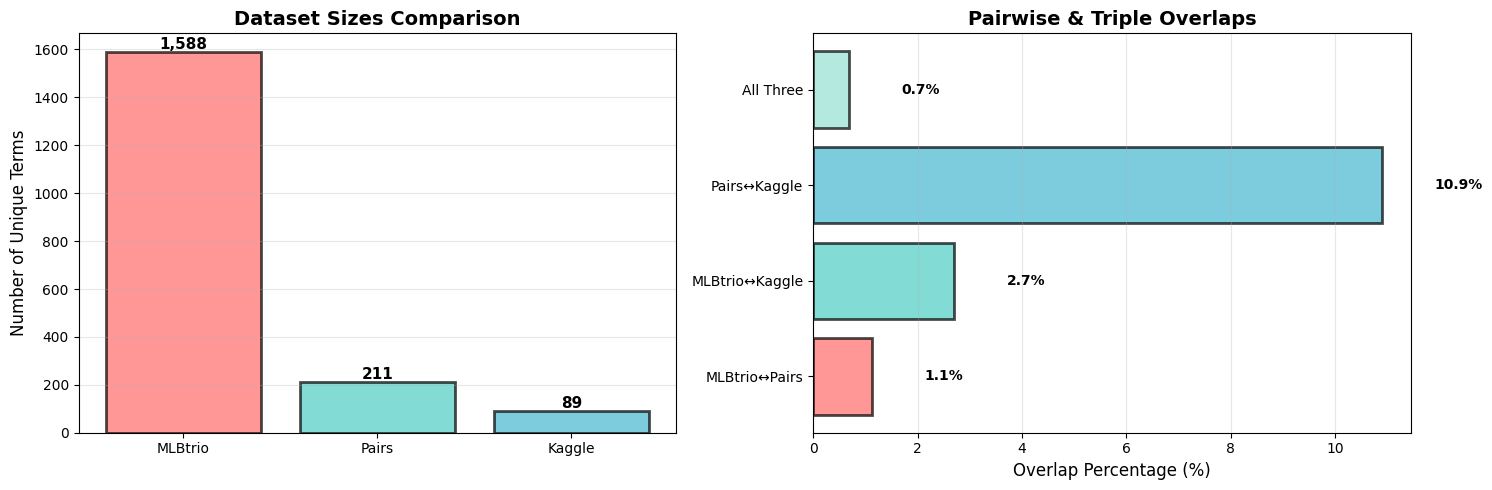

In [52]:
# --- Create sets of slang terms (normalized) ---
slang_mlbtrio = set(df_mlbtrio.Slang.str.lower())
slang_pair = set(chain.from_iterable(slang_lists))
slang_kaggle  = set(df_kaggle.Slang.str.lower())
print(f"Total unique slang terms in slang_kaggle: {len(slang_kaggle)}")
# --- Compute pairwise intersections and differences ---

# Pair 1: MLBtrio vs Pairs
intersection_1_2 = slang_mlbtrio.intersection(slang_pair)
only_in_mlbtrio = slang_mlbtrio - slang_pair
only_in_pairs = slang_pair - slang_mlbtrio

# Pair 2: MLBtrio vs Kaggle
intersection_1_3 = slang_mlbtrio.intersection(slang_kaggle)
only_in_kaggle_vs_mlbtrio = slang_kaggle - slang_mlbtrio

# Pair 3: Pairs vs Kaggle
intersection_2_3 = slang_pair.intersection(slang_kaggle)
only_in_kaggle_vs_pairs = slang_kaggle - slang_pair

# Triple intersection (all three)
intersection_all = slang_mlbtrio.intersection(slang_pair).intersection(slang_kaggle)

# --- Print comprehensive summary ---
print("=" * 70)
print("SLANG DICTIONARY COMPARISON - THREE DATASETS")
print("=" * 70)

print(f"\nDataset Sizes:")
print(f"  MLBtrio/genz-slang-dataset: {len(slang_mlbtrio):,} unique terms")
print(f"  Programmer-RD-AI/genz-slang-pairs-1k: {len(slang_pair):,} unique terms")
print(f"  Gen Z Words and Phrases Dataset: {len(slang_kaggle):,} unique terms")

print(f"\nPairwise Overlaps:")
print(f"  MLBtrio vs Pairs: {len(intersection_1_2)} shared ({len(intersection_1_2) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  MLBtrio vs Kaggle: {len(intersection_1_3)} shared ({len(intersection_1_3) / len(slang_mlbtrio) * 100:.2f}% of MLBtrio)")
print(f"  Pairs vs Kaggle: {len(intersection_2_3)} shared ({len(intersection_2_3)/len(slang_pair)*100:.2f}% of Pairs)")

print(f"\nTriple Intersection (in all three): {len(intersection_all)} terms")

print(f"\nUnique Terms (only in one dataset):")
print(f"  Only in MLBtrio: {len(only_in_mlbtrio):,}")
print(f"  Only in Pairs: {len(only_in_pairs):,}")
print(f"  Only in Kaggle: {len(only_in_kaggle_vs_pairs):,}")

# --- Visualizations ---

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: Dataset sizes
ax1 = axes[0]
dataset_names = ['MLBtrio', 'Pairs', 'Kaggle']
dataset_sizes = [len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

bars = ax1.bar(dataset_names, dataset_sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Unique Terms', fontsize=12)
ax1.set_title('Dataset Sizes Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

for bar, size in zip(bars, dataset_sizes):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{int(size):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Chart 2: Overlap percentages
ax2 = axes[1]
overlap_labels = ['MLBtrio↔Pairs', 'MLBtrio↔Kaggle', 'Pairs↔Kaggle', 'All Three']
overlap_percentages = [
    len(intersection_1_2) / max(len(slang_mlbtrio), len(slang_pair)) * 100,
    len(intersection_1_3) / max(len(slang_mlbtrio), len(slang_kaggle)) * 100,
    len(intersection_2_3) / max(len(slang_pair), len(slang_kaggle)) * 100,
    len(intersection_all) / max(len(slang_mlbtrio), len(slang_pair), len(slang_kaggle)) * 100
]

ax2.barh(overlap_labels, overlap_percentages,
         color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#95E1D3'],
         alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_xlabel('Overlap Percentage (%)', fontsize=12)
ax2.set_title('Pairwise & Triple Overlaps', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for i, v in enumerate(overlap_percentages):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('three_dataset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Since it is only 18 slang terms that is overlapping, there is a reason for merging these dataset. However, first we have to align the dataset, such as both of them will contain the same columns; Slang, Description, Example, Context. The Programmer-RD-AI/genz-slang-pairs-1k contains the Example and the normalized text, and we have created the terms from the text by using a LLM to detect the term. However now we have the term, but we have multiple example of the same term and in some examples there is multiple slang terms.

# This section is about aligning the data, so that they have the same fields

## Aligning MLBrio
In this section we want to make use MLBtrio dataset has the Informal_Text fields as there is in the Pairs dataset

#### Add informal text that does contain slang words
Then we create a prompt for telling the LLM what to do with the data.
Rewrite normal English text so the purpose aligns with the original slang meaning. This ensures the refined text captures the same sentiment/intent as the slang.

In [ ]:
prompt_informal_with_slang = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_informal_with_slang,
    output_column="Informal_Text"
)
df_mlbtrio.Informal_Text

See the new column created in the dataset

In [ ]:
df_mlbtrio.head(5)

Save the dataset to a file

In [ ]:
df_mlbtrio.to_csv(genz_slang, index=False)

#### Add informal text that does not contain slang words


In [ ]:
prompt_informal   = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio.head(5),
    prompt_template=prompt_informal,
    output_column="Informal_Text_Without_Slang"
)
df_mlbtrio.Informal_Text_Without_Slang

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv(genz_slang, index=False)

#### Add formal text

In [ ]:
prompt_formal = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use formal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_mlbtrio = client.batch_process(
    df_mlbtrio,
    prompt_template=prompt_formal,
    output_column="Formal_Text"
)
df_mlbtrio.Formal_Text

In [ ]:
df_mlbtrio.head(5)

In [ ]:
df_mlbtrio.to_csv(basepath + genz_slang, index=False)

## Aligning Kaggle Gen ZZ words
In this section we want to make use Kaggle dataset has the Informal_Text and the Content fields as there is in the MLBrio dataset

In [83]:
df_kaggle = pd.read_csv(basepath + gen_zz_words)

In [22]:
prompt_informal   = """You are a language refinement expert. Rewrite the following text to preserve the original intent and sentiment of the slang term '{Slang}' (meaning: {Description}).

Requirements:
- Use informal, conversational English without slang
- Capture the same emotional tone and purpose as the original slang
- Output only UTF-8 text characters (no emojis or special symbols)
- Provide ONLY the rewritten sentence with no explanations, quotes, or parentheses
- Do not include any meta-commentary about the task

Original text: {Example}

Rewritten version:"""

df_kaggle = client.batch_process(
    df_kaggle,
    prompt_template=prompt_informal,
    output_column="Informal_Text_Without_Slang"
)
df_kaggle.Informal_Text_Without_Slang

Processing to Informal_Text_Without_Slang: 100%|██████████| 204/204 [00:53<00:00,  3.79it/s]


0               That brand new tune is a real hum-ditty!
1           I'm skedaddling, catch you on the flip side.
2      She was heavily criticized and shunned followi...
3                              I'm taking it easy today.
4                                   That video was awks.
                             ...                        
199                               Why are you so bitter?
200                            Nailed that presentation!
201                        Was that a subtle jab at all?
202              Keep your eyes open to what's going on.
203                    She has such a voluptuous figure.
Name: Informal_Text_Without_Slang, Length: 204, dtype: object

In [84]:
df_kaggle = df_kaggle[['Slang', 'Description', 'Example', 'Informal_Text_Without_Slang', 'Popularity']]

In [85]:
df_kaggle.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang,Popularity
0,Bop,A song that's really good.,That new track is a bop.,That fresh tune is a real humdinger.,Medium
1,Bounce,To leave or exit.,"I'm bouncing, see you later.","I've got to split, catch you soon.",Medium
2,Cancelled,Publicly denounced and rejected.,She got cancelled after that post.,She was publicly denounced following that post.,High
3,Chill,Relaxed or easy-going.,I'm just chilling today.,I'm taking it easy today.,High
4,Cringe,Embarrassing or awkward.,That video was cringe.,That video was mortifyingly awkward.,High


In [65]:
df_kaggle.to_csv(gen_zz_words, index=False)

#### Add context field

In [86]:
prompt_context = """You are a conversational analysis expert specializing in concise context descriptions. Output exactly 2-3 sentences. Maximum 40 words.

Slang: {Slang}
Meaning: {Description}
Example: {Example}

Output 2-3 sentences describing WHEN, WHERE, and WHO uses this term. Format: [social context and usage]
Requirements:
- NO QUOTES, NO BRACKETS, NO META-COMMENTARYs
- Do NOT write the slang term itself in the context
- Describe the usage, not the slang word
- Focus on: social setting (who, when, where), sentiment/tone, demographics

Good examples:
Typically used in conversations to celebrate success, achievements, or positive outcomes
Originally used in activist circles, it has since been co-opted and sometimes used sarcastically.
Often used in informal speech to indicate imminent action, popular in certain dialects of English.


Example text: {Example}

Context:"""

df_kaggle = client.batch_process(
    df_kaggle,
    prompt_template=prompt_context,
    output_column="Context"
)
df_kaggle.Context

Processing to Context: 100%|██████████| 204/204 [03:10<00:00,  1.07it/s]


0      Typically used among friends or on social medi...
1      Often employed casually among friends or peers...
2      Primarily employed in digital discussions, oft...
3      Casual setting among friends or peers, often u...
4      Typically used by younger generations in casua...
                             ...                        
199    Typically utilized in casual conversations amo...
200    Typically employed in casual conversations amo...
201    In casual conversations among teenagers and yo...
202    Often employed in contemporary discussions foc...
203    Often utilized among peers in casual social se...
Name: Context, Length: 204, dtype: object

In [88]:
df_kaggle = df_kaggle[['Slang', 'Description', 'Example', 'Context', 'Informal_Text_Without_Slang', 'Popularity']]

In [89]:
df_kaggle.head(5)

,Slang,Description,Example,Context,Informal_Text_Without_Slang,Popularity
0,Bop,A song that's really good.,That new track is a bop.,Typically used among friends or on social medi...,That fresh tune is a real humdinger.,Medium
1,Bounce,To leave or exit.,"I'm bouncing, see you later.",Often employed casually among friends or peers...,"I've got to split, catch you soon.",Medium
2,Cancelled,Publicly denounced and rejected.,She got cancelled after that post.,"Primarily employed in digital discussions, oft...",She was publicly denounced following that post.,High
3,Chill,Relaxed or easy-going.,I'm just chilling today.,"Casual setting among friends or peers, often u...",I'm taking it easy today.,High
4,Cringe,Embarrassing or awkward.,That video was cringe.,Typically used by younger generations in casua...,That video was mortifyingly awkward.,High


In [91]:
df_kaggle.to_csv(basepath + gen_zz_words, index=False)

## Aligning Pairs
In this section we want to make use Pairs dataset has the Description and the Context fields as there is in the MLBrio dataset

In [4]:
df_pairs = pd.read_csv(basepath + genz_slang_pairs)

First we have to figure out how too spilt op the data since the Slang column has repeated the same words multiple times. We are not sure yet and this up for discussion. Reward Attribution Problem: PPO uses rewards to update policies. With multiple slang terms, it's unclear which term(s) should receive credit. If the model generates "vibing, no cap" and gets a reward, did it succeed because of multiple entries on one slang term

In [5]:
df_pairs.Slang[5]

'tired, chill'

So split Multi-Slang Entries into multiple entries

In [6]:
def split_multi_slang(df):
    """
    Convert multi-slang entries into separate rows
    E.g., "vibing, no cap" becomes two rows with same Example
    """
    rows = []
    for idx, row in df.iterrows():
        slang_terms = [s.strip() for s in row['Slang'].split(',')]

        for slang in slang_terms:
            new_row = row.copy()
            new_row['Slang'] = slang  # Single term
            new_row['Original_Slang_List'] = ','.join(slang_terms)  # Keep reference
            rows.append(new_row)

    return pd.DataFrame(rows)

# Apply transformation
df_split = split_multi_slang(df_pairs)

print(f"Before: {len(df_pairs)} rows, {df_pairs['Slang'].nunique()} unique terms")
print(f"After: {len(df_split)} rows, {df_split['Slang'].nunique()} unique terms")

Before: 1005 rows, 378 unique terms
After: 1372 rows, 242 unique terms


In [86]:
df_unique = df_split.groupby('Slang').first().reset_index()
df_unique
# Result: 378 rows (one per unique slang term)

,Slang,Example,Informal_Text_Without_Slang,Original_Slang_List
0,"""hella""",I'm hella drained today.,I'm feeling really tired today.,"""hella"""
1,"""java"" is a common misspelling or shortening o...",I'm just finna snag some java before I dip.,I'm just going to grab some coffee before I he...,"finna,java (in this context,""java"" is a common..."
2,"""mad""",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,"""mad"""
3,Chillin',"Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Chillin'
4,Netflix,I'm just chillin' and gonna Netflix and chill ...,I'm just going to relax and watch a movie toni...,"chillin,Netflix,chill"
...,...,...,...,...
237,yolo,"I'm finna get some coffee, yolo? Do you wanna ...",I'm going to grab some coffee. Do you want to ...,"finna,yolo"
238,z's,"I'm totally drained today, need to catch some ...","I'm really tired today, I think I need some rest.",z's
239,z's (Z's stands for sleep),"I'm super drained today, I gotta catch some z's.","I'm really tired today, I think I need a nap.",z's (Z's stands for sleep)
240,zapped,I'm mad zapped after pulling a midnight cram s...,I'm so tired after staying up all night studying.,zapped


In [87]:
df_aggregated = df_split.groupby('Slang').agg({
    'Example': lambda x: list(x),
    'Informal_Text_Without_Slang': lambda x: list(x)
}).reset_index()
# Then generate a single Description/Context based on all examples
df_aggregated

,Slang,Example,Informal_Text_Without_Slang
0,"""hella""","[I'm hella drained today., I'm hella drained t...","[I'm feeling really tired today., I'm feeling ..."
1,"""java"" is a common misspelling or shortening o...",[I'm just finna snag some java before I dip.],[I'm just going to grab some coffee before I h...
2,"""mad""",[I'm mad tired today 'cause I pulled an all-ni...,[I'm really tired today because I stayed up la...
3,Chillin',"[Fr, I’m just chillin’ at home tonight, no cap...","[Yeah, I think I'm going to stay in tonight an..."
4,Netflix,[I'm just chillin' and gonna Netflix and chill...,[I'm just going to relax and watch a movie ton...
...,...,...,...
237,yolo,"[I'm finna get some coffee, yolo? Do you wanna...",[I'm going to grab some coffee. Do you want to...
238,z's,"[I'm totally drained today, need to catch some...","[I'm really tired today, I think I need some r..."
239,z's (Z's stands for sleep),"[I'm super drained today, I gotta catch some z...","[I'm really tired today, I think I need a nap.]"
240,zapped,[I'm mad zapped after pulling a midnight cram ...,[I'm so tired after staying up all night study...


In [7]:
df_unique = df_split.loc[df_pairs.groupby('Slang')['Example'].apply(lambda x: x.str.len().idxmin())]
df_unique

,Slang,Example,Informal_Text_Without_Slang,Original_Slang_List
45,"""hella""",I'm hella drained today.,I'm feeling really tired today.,"""hella"""
83,"""mad""",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,"""mad"""
897,Chillin',"Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Chillin'
943,Chillin',"Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","Chillin',vibing"
943,vibing,"Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","Chillin',vibing"
...,...,...,...,...
892,yeet,"Yo, wanna yeet for some chow later? 🔥","Hey, do you want to go grab some food later?",yeet
459,yo,"Yo, did you catch the new ep of that show yest...","Hey, did you see the new episode of that show ...",yo
484,z's,"Lowkey exhausted today, I gotta catch some Z's.","I'm just really tired today, I think I need so...",z's
64,z's (Z's stands for sleep),"I'm super drained today, I gotta catch some z's.","I'm really tired today, I think I need a nap.",z's (Z's stands for sleep)


In [74]:
# Create one Description per slang term (378 rows)
df_terms = df_pairs.groupby('Slang').agg({
    'Example': lambda x: list(x)[:5],  # Keep up to 5 examples
    'Informal_Text_Without_Slang': 'first'
}).reset_index()

# Generate Description using multiple examples as context
# This gives you a comprehensive understanding of the term
df_terms

,Slang,Example,Informal_Text_Without_Slang
0,"""hella""","[I'm hella drained today., I'm hella drained t...",I'm feeling really tired today.
1,"""mad""",[I'm mad tired today 'cause I pulled an all-ni...,I'm really tired today because I stayed up lat...
2,Chillin',"[Fr, I’m just chillin’ at home tonight, no cap.]","Yeah, I think I'm going to stay in tonight and..."
3,"Chillin', vibing","[Yo, I'm just chillin' at my place and vibing ...","Hey, I'm just relaxing at home and listening t..."
4,"OOTD, vibing, no cap","[OOTD, just vibing with the crew today, no cap.]",I'm just planning to hang out with friends thi...
...,...,...,...
373,yeet,"[I'm down bad but gotta yeet to work anyway., ...",I'm just really tired today but I still have t...
374,yo,"[Yo, did you catch the new ep of that show yes...","Hey, did you see the new episode of that show ..."
375,z's,"[I'm totally drained today, need to catch some...","I'm really tired today, I think I need some rest."
376,z's (Z's stands for sleep),"[I'm super drained today, I gotta catch some z...","I'm really tired today, I think I need a nap."


In [28]:
# Get the Slang
df_mlbtrio = pd.read_csv(basepath + genz_slang)

for i in range(5):
    print("Slang: " + df_mlbtrio.Slang[i] +
          ", Description: " + df_mlbtrio.Description[i] +
          ", Example: " + df_mlbtrio.Example[i] +
          ", Informal_Text: " + df_mlbtrio.Informal_Text[i])

Slang: W, Description: Shorthand for win, Example: Got the job today, big W!, Informal_Text: Nailed it today, big win!
Slang: L, Description: Shorthand for loss/losing, Example: I forgot my wallet at home, that’s an L., Informal_Text: Dang it, left my wallet at home – that's a loss for sure!
Slang: L+ratio, Description: Response to a comment or action on the internet that is particularly bad., Example: Your tweet got 5 likes and 100 replies calling you out. L + ratio., Informal_Text: Dang, your tweet only managed five likes but a hundred people called you out on it. Big ol' ratio, mate!
Slang: Dank, Description: excellent or of very high quality, Example: That meme is so dank!, Informal_Text: That meme's fire as hell!
Slang: Cheugy, Description: Derogatory term for Millennials. Used when millennials are perceived to be excessively attempting to be trendy or stylish., Example: That phrase is so cheugy, no one says that anymore., Informal_Text: Man, that's totally cringey – nobody's usin

In [60]:
df_unique = pd.read_csv(basepath + "genz-slang-pairs-1k-unique.csv")

In [61]:
# Prompt for generating Description field
prompt_context = prompt_context = """You are a linguistics expert specializing in concise definitions. Output exactly 1 line. Maximum 10 words.

Slang: {Slang}
Example: {Example}

Output ONE line only. Format: [short definition]
No brackets, no labels, no explanation, no example, no context, not allowed to used the Slang to describe itself.

Bad: The term "hella" is an informal contraction of "hell of," originating from California's Bay Area in the United States. It is used as an intensifier to emphasize a strong feeling, emotion, or degree. In the sentence "I'm hella drained today," the speaker is expressing extreme feelings of exhaustion or tiredness.
Good: being politically aware
Good: The greatest of all time
Good: Fam is a shorter word for family, but don't be fooled– it can be used to describe your friends or the way Millennials use "bro".

Definition:"""

df_unique = client.batch_process(
    df_unique,
    prompt_template=prompt_context,
    output_column="Description"
)
df_unique.Description

Processing to Description: 100%|██████████| 650/650 [03:41<00:00,  2.93it/s]


0                  Intensifier meaning extremely or very
1                 Angry or frustrated, often informally.
2         Casually relaxing, informally enjoying leisure
3      Casual relaxation, typically with social inter...
4      Enjoying oneself in a relaxed, positive manner...
                             ...                        
645    Casual exclamation indicating enthusiasm or ap...
646    Informal greeting, often used in casual conver...
647    Sleep (noun): informal abbreviation for "sleep...
648    A common slang term referring to sleep. Exampl...
649              intensified exasperation or frustration
Name: Description, Length: 650, dtype: object

In [62]:
df_unique.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."


In [13]:
df_unique = df_unique[['Slang', 'Description', 'Example', 'Informal_Text_Without_Slang']]
df_unique.head(5)


,Slang,Description,Example,Informal_Text_Without_Slang
45,"""hella""","The term ""hella"" is an informal contraction of...",I'm hella drained today.,I'm feeling really tired today.
83,"""mad""","The slang term ""mad"" as used in the sentence ""...",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...
897,Chillin',"The slang term ""chillin'"" as used in the phras...","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and..."
943,Chillin',"The term ""chillin'"" is a colloquial expression...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."
943,vibing,"The slang term ""vibing,"" as used in the given ...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t..."


In [63]:
df_unique.to_csv(basepath + "genz-slang-pairs-1k-unique.csv", index=False)

Context fields as there is in the MLBrio dataset

In [77]:
prompt_context = """You are a conversational analysis expert specializing in concise context descriptions. Output exactly 2-3 sentences. Maximum 40 words.

Slang: {Slang}
Meaning: {Description}
Example: {Example}

Output 2-3 sentences describing WHEN, WHERE, and WHO uses this term. Format: [social context and usage]
Requirements:
- NO QUOTES, NO BRACKETS, NO META-COMMENTARYs
- Do NOT write the slang term itself in the context
- Describe the usage, not the slang word
- Focus on: social setting (who, when, where), sentiment/tone, demographics

Good examples:
Typically used in conversations to celebrate success, achievements, or positive outcomes
Originally used in activist circles, it has since been co-opted and sometimes used sarcastically.
Often used in informal speech to indicate imminent action, popular in certain dialects of English.


Example text: {Example}

Context:"""

df_unique = client.batch_process(
    df_unique,
    prompt_template=prompt_context,
    output_column="Context"
)
df_unique.Context

Processing to Context: 100%|██████████| 650/650 [10:20<00:00,  1.05it/s]


0      Typically expressed in casual conversations, p...
1      Typically expressed among peers or casual acqu...
2      Typically utilized among friends or peers duri...
3      In informal settings among friends or peers, o...
4      In casual social settings, often among friends...
                             ...                        
645    In casual, youthful social settings, typically...
646    In casual settings among friends or peers, oft...
647    Commonly used among friends and peers during c...
648    Typically utilized in informal settings among ...
649    Often utilized among young adults or students ...
Name: Context, Length: 650, dtype: object

In [78]:
df_unique.head(5)

,Slang,Description,Example,Informal_Text_Without_Slang,Context
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,I'm feeling really tired today.,"Typically expressed in casual conversations, p..."
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,I'm really tired today because I stayed up lat...,Typically expressed among peers or casual acqu...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.","Yeah, I think I'm going to stay in tonight and...",Typically utilized among friends or peers duri...
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","In informal settings among friends or peers, o..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","Hey, I'm just relaxing at home and listening t...","In casual social settings, often among friends..."


In [79]:
df_unique = df_unique[['Slang', 'Description', 'Example', 'Context', 'Informal_Text_Without_Slang']]
df_unique.head(5)


,Slang,Description,Example,Context,Informal_Text_Without_Slang
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","In informal settings among friends or peers, o...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."


In [80]:
df_unique.to_csv(basepath + "genz-slang-pairs-1k-unique.csv", index=False)

## Data assemble

In [39]:
df_unique = pd.read_csv(basepath + "genz-slang-pairs-1k-unique.csv")
df_mlbtrio = pd.read_csv(basepath + genz_slang)
df_kaggle = pd.read_csv(basepath + gen_zz_words)

In [40]:
# Select only the columns you need and rename last column
columns_to_keep = ["Slang", "Description", "Example", "Context", "Informal_Text_Without_Slang"]

df_unique_filtered = df_unique[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})
df_mlbtrio_filtered = df_mlbtrio[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})
df_kaggle_filtered = df_kaggle[columns_to_keep].rename(columns={"Informal_Text_Without_Slang": "Neutral_Text"})

# Merge all three datasets
df_merged = pd.concat([df_unique_filtered, df_mlbtrio_filtered, df_kaggle_filtered], ignore_index=True)
print(f"Merged dataset shape: {df_merged.shape}")

Merged dataset shape: (2633, 5)


In [41]:
df_merged.head(5)

,Slang,Description,Example,Context,Neutral_Text
0,"""hella""",Intensifier meaning extremely or very,I'm hella drained today.,"Typically expressed in casual conversations, p...",I'm feeling really tired today.
1,"""mad""","Angry or frustrated, often informally.",I'm mad tired today 'cause I pulled an all-nig...,Typically expressed among peers or casual acqu...,I'm really tired today because I stayed up lat...
2,Chillin',"Casually relaxing, informally enjoying leisure","Fr, I’m just chillin’ at home tonight, no cap.",Typically utilized among friends or peers duri...,"Yeah, I think I'm going to stay in tonight and..."
3,Chillin',"Casual relaxation, typically with social inter...","Yo, I'm just chillin' at my place and vibing t...","In informal settings among friends or peers, o...","Hey, I'm just relaxing at home and listening t..."
4,vibing,"Enjoying oneself in a relaxed, positive manner...","Yo, I'm just chillin' at my place and vibing t...","In casual social settings, often among friends...","Hey, I'm just relaxing at home and listening t..."


In [42]:
df_merged.to_csv(basepath + "genz_slang_data.csv", index=False)

In [43]:
analysis_merged : Dict = analyser.analyze(
    df_merged,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_merged)
analyser.show_duplication_analysis(analysis_merged)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"2,633"
1,Unique (Case-Sensitive),"1,901"
2,Unique (Lowercase),"1,844"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),30.0%
1,Most Common Term,'drained'
2,Most Common Count,48
3,Original Cases,['drained']


The obtained duplication is of 30%, therefore a drop duplicate stage is added. This stage is case sensitive, meaning that same words but with different capitalizations will be reckoned as different due to the different descriptions and meaning provided by the dictionaries.

In [46]:
df_merged_nodup = df_merged.drop_duplicates(subset=["Slang"])

analysis_merged : Dict = analyser.analyze(
    df_merged_nodup,
    column='Slang',
    dataset_name='Gen Z Words and Phrases Dataset'
)
analyser.show_total_statistics(analysis_merged)
analyser.show_duplication_analysis(analysis_merged)

df_merged_nodup.to_csv(basepath + "genz_slang_data.csv", index=False)


DATASET ANALYSIS: Gen Z Words and Phrases Dataset

1. Total Statistics:


,Metric,Count
0,Total Rows,"1,901"
1,Unique (Case-Sensitive),"1,901"
2,Unique (Lowercase),"1,844"


2. Duplication Analysis:


,Metric,Value
0,Duplication Rate (%),3.0%
1,Most Common Term,'fam'
2,Most Common Count,3
3,Original Cases,"['fam', 'Fam', 'FAM']"


In [47]:
genz = pd.read_csv(basepath + "genz_slang_data.csv")


print("Loading TL;DR dataset from Hugging Face...")
dataset = load_dataset("trl-lib/tldr", download_mode=DownloadMode.REUSE_CACHE_IF_EXISTS)

train_ds = dataset["train"]
val_ds = dataset["validation"]
test_ds = dataset["test"]

print(f"Dataset sizes: Train={len(train_ds)}, Val={len(val_ds)}, Test={len(test_ds)}")

total = len(train_ds) + len(val_ds) + len(test_ds)
print(f"Dataset split percentages: Train={len(train_ds)/total*100:.2f}%, Val={len(val_ds)/total*100:.2f}%, Test={len(test_ds)/total*100:.2f}%")
pd.DataFrame(train_ds).head(5)



Loading TL;DR dataset from Hugging Face...


Generating test split: 100%|██████████| 6553/6553 [00:00<00:00, 139609.16 examples/s]


Dataset sizes: Train=116722, Val=6447, Test=6553
Dataset split percentages: Train=89.98%, Val=4.97%, Test=5.05%


,prompt,completion
0,SUBREDDIT: r/relationships\n\nTITLE: I (f/22) ...,I still have contact with an old ex's friends...
1,SUBREDDIT: r/loseit\n\nTITLE: SV & NSV! Keepin...,"Progress is still happening, even when you th..."
2,SUBREDDIT: r/relationships\n\nTITLE: Me [19F] ...,My skin is scarred badly; what could I do/say...
3,SUBREDDIT: r/personalfinance\n\nTITLE: Priorit...,$14k in student debt (all <5%) and need to sa...
4,SUBREDDIT: r/relationships\n\nTITLE: My[25m] g...,"GF is a meanie-bo-beanie when I'm nice, and a..."


The two main datasets used in this project from this point onward are the merged Gen Z dataset and the TL;DR corpus. As shown above, both datasets have manageable sizes (TL;DR: 116,722 entries; Gen Z: 6,553 entries). Both datasets are stored as CSV files with UTF-8 encoded text, contain no missing values or duplicate entries, and their length distributions will be analyzed in the following sections along with other relevant metrics.

In [ ]:
# Load Gen Z slang data
print("Loading Gen Z slang data...")
df_genz = pd.read_csv('Data/genz_slang_data.csv')
print(f"✓ Loaded {len(df_genz)} examples\n")

# Load TLDR dataset
print("Loading TLDR dataset...")
tldr_ds = load_dataset("trl-lib/tldr")
tldr_df = pd.DataFrame(tldr_ds['train'])
print(f"✓ Loaded {len(tldr_df)} TLDR examples\n")

# Show sample
print("Gen Z slang sample:")
print(df_genz[['Slang', 'Example', 'Neutral_Text']].head(3))
print(f"\nTLDR sample (first 2 chars of completion):")
print(tldr_df['completion'].iloc[:100])


In [ ]:
# Initialize RAG with all components
from scripts.libs.rag_components import GenZSlangRAG


rag = GenZSlangRAG(
    df_genz=df_genz,
    embedding_model_name="all-MiniLM-L6-v2",
    ollama_base_url="http://localhost:11434",
    ollama_model="mistral",
    top_k=5
)

# Build retrieval index
rag.index_examples(df_genz)
print("RAG initialized and indexed\n")


## TL;DR data analysis

### Exploratory Data Analysis

The TL;DR dataset was explored to understand its structure and content. The dataset consists of 116,722 examples, each containing a Reddit post (*prompt*) and its corresponding TL;DR summary (*completion*). No missing values were found in either column. Text length analysis showed that posts contain an average of about 266 words, while summaries average around 27 words, indicating a high level of compression (roughly a 10:1 ratio), this characteristic length can be ilustrated by generating a histogram of the text lengths, which shows that the spread (standard deviation) of the completion is seven times smaller than the prompt, therefore TL;DR sumaries have a very consistent length that we aim to keep in the ouput of our model.



TL;DR Dataset Overview
Shape: (116722, 2)
Columns: ['prompt', 'completion']

                                              prompt  \
0  SUBREDDIT: r/relationships\n\nTITLE: I (f/22) ...   
1  SUBREDDIT: r/loseit\n\nTITLE: SV & NSV! Keepin...   
2  SUBREDDIT: r/relationships\n\nTITLE: Me [19F] ...   

                                          completion  
0   I still have contact with an old ex's friends...  
1   Progress is still happening, even when you th...  
2   My skin is scarred badly; what could I do/say...  

Missing values:
 prompt        0
completion    0
dtype: int64

=== Text Length Statistics ===
          prompt_len  completion_len
count  116722.000000   116722.000000
mean      266.400816       27.021624
std        77.649418        5.891135
min        11.000000        7.000000
25%       205.000000       22.000000
50%       266.000000       26.000000
75%       330.000000       31.000000
max       442.000000       47.000000

=== Variance, Std Dev, and Coefficient of Variati

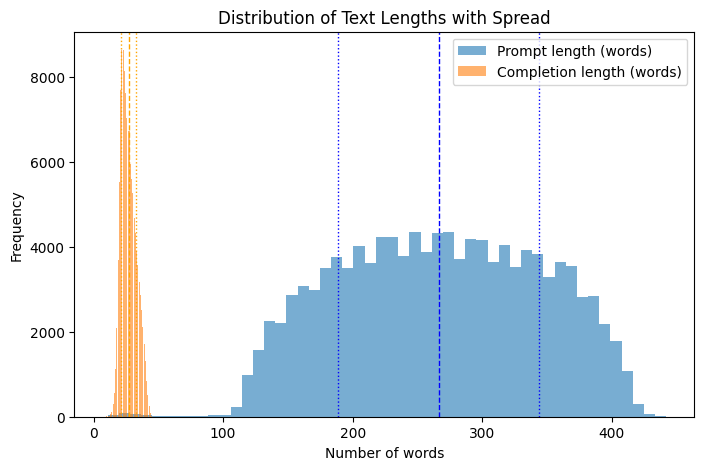


Average compression ratio (prompt/completion): 10.247919755335309


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load dataset ---
splits = {
    'train': 'data/train-00000-of-00001.parquet',
    'validation': 'data/validation-00000-of-00001.parquet',
    'test': 'data/test-00000-of-00001.parquet'
}

df = pd.read_parquet("hf://datasets/trl-lib/tldr/" + splits["train"])

# --- Basic info ---
print("="*50)
print("TL;DR Dataset Overview")
print("="*50)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}\n")
print(df.head(3))  # show sample examples

# --- Missing values check ---
print("\nMissing values:\n", df.isnull().sum())

# --- Compute text lengths ---
df["prompt_len"] = df["prompt"].astype(str).str.split().apply(len)
df["completion_len"] = df["completion"].astype(str).str.split().apply(len)

# --- Summary statistics ---
print("\n=== Text Length Statistics ===")
print(df[["prompt_len", "completion_len"]].describe())

# --- Variance, Std Dev, CV ---
prompt_var = df["prompt_len"].var()
completion_var = df["completion_len"].var()
prompt_std = df["prompt_len"].std()
completion_std = df["completion_len"].std()
prompt_cv = prompt_std / df["prompt_len"].mean()
completion_cv = completion_std / df["completion_len"].mean()

print("\n=== Variance, Std Dev, and Coefficient of Variation ===")
print(f"Prompt length: Variance = {prompt_var:.2f}, Std Dev = {prompt_std:.2f}, CV = {prompt_cv:.2f}")
print(f"Completion length: Variance = {completion_var:.2f}, Std Dev = {completion_std:.2f}, CV = {completion_cv:.2f}")

# --- Show a few example pairs ---
print("\n=== Example Prompt → Completion Pairs ===")
for i in range(3):
    print(f"\n[{i+1}] Prompt:\n{df['prompt'].iloc[i][:250]}...")
    print(f"Completion (TL;DR): {df['completion'].iloc[i]}")

# --- Plot distributions of text lengths ---
plt.figure(figsize=(8,5))
plt.hist(df["prompt_len"], bins=50, alpha=0.6, label="Prompt length (words)")
plt.hist(df["completion_len"], bins=50, alpha=0.6, label="Completion length (words)")

# Mean ± 1 std lines for visual spread
plt.axvline(df["prompt_len"].mean(), color='blue', linestyle='dashed', linewidth=1)
plt.axvline(df["prompt_len"].mean() + prompt_std, color='blue', linestyle='dotted', linewidth=1)
plt.axvline(df["prompt_len"].mean() - prompt_std, color='blue', linestyle='dotted', linewidth=1)

plt.axvline(df["completion_len"].mean(), color='orange', linestyle='dashed', linewidth=1)
plt.axvline(df["completion_len"].mean() + completion_std, color='orange', linestyle='dotted', linewidth=1)
plt.axvline(df["completion_len"].mean() - completion_std, color='orange', linestyle='dotted', linewidth=1)

plt.legend()
plt.title("Distribution of Text Lengths with Spread")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

# --- Optional: Ratio between full text and summary ---
df["compression_ratio"] = df["prompt_len"] / df["completion_len"]
print("\nAverage compression ratio (prompt/completion):", df["compression_ratio"].mean())


In order to assess the quality of the TL;DR dataset we perform a more thorough analysis with the goal of evaluating data cleanliness, diversity, alignment between prompts and summaries, token length distributions, potential privacy concerns, and establishing a baseline for summarization performance.

These analysis shows that the dataset appears to be high-quality and predominantly English, as evidenced by the language fraction of 1.0 for the training set. Duplicate rates are extremely low, with only about 0.13% of training examples being exact duplicates and negligible duplicates in the validation and test sets, while near-duplicate prompts across splits are also minimal, indicating very little data leakage. Prompt–completion alignment metrics show that the lexical overlap is low (mean Jaccard ~0.097). 

Tokenization statistics reveal that 95% of prompts fit within 472 tokens and completions within 45 tokens, with the combined 95th percentile at 506 tokens—guiding a reasonable maximum sequence length for model training. 

Finally, the echo baseline, which simply outputs truncated prompts, performs poorly (ROUGE-1 ≈ 0.224, ROUGE-2 ≈ 0.07, ROUGE-L ≈ 0.174, chrF ≈ 18.8), confirming that the dataset presents a non-trivial summarization task and leaves substantial room for model improvement. Overall, these metrics indicate a clean, English-focused summarization dataset with low duplication, minimal PII, and a realistic challenge for training models.

In [13]:
import langdetect
import rouge_score

# 0) Load validation/test and record split sizes
val_df = pd.read_parquet("hf://datasets/trl-lib/tldr/" + splits["validation"])
test_df = pd.read_parquet("hf://datasets/trl-lib/tldr/" + splits["test"])

print({"train_n": len(df), "val_n": len(val_df), "test_n": len(test_df)})

# 1) Normalize text (NFKC + whitespace)
import unicodedata, regex as rx

def normalize_text(s):
    s = "" if s is None else s
    s = unicodedata.normalize("NFKC", str(s))
    s = rx.sub(r"\s+", " ", s).strip()
    return s

for d in (df, val_df, test_df):
    d["prompt"] = d["prompt"].map(normalize_text)
    d["completion"] = d["completion"].map(normalize_text)

# 2) Language ID sampling
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

def sample_lang_distribution(frame, n=2000):
    import numpy as np
    idx = np.random.RandomState(0).choice(len(frame), size=min(n, len(frame)), replace=False)
    langs = []
    for i in idx:
        text = (frame.iloc[i]["prompt"] + " " + frame.iloc[i]["completion"])[:1000]
        try:
            langs.append(detect(text))
        except:
            langs.append("unk")
    return pd.Series(langs).value_counts(normalize=True)

lang_train = sample_lang_distribution(df)
lang_val = sample_lang_distribution(val_df)
lang_test = sample_lang_distribution(test_df)
print("Language fraction (train):\n", lang_train.head())

# 3) Deduplication and leakage checks
import hashlib

def md5(s): return hashlib.md5(s.encode("utf-8")).hexdigest()

for d in (df, val_df, test_df):
    d["pair_hash"] = (d["prompt"] + " || " + d["completion"]).map(md5)
    d["prompt_sig"] = d["prompt"].str.lower().str.replace(r"[^a-z0-9]+", " ", regex=True).str.strip()

# Exact duplicates within each split
dup_train = 1 - df["pair_hash"].nunique()/len(df)
dup_val = 1 - val_df["pair_hash"].nunique()/len(val_df)
dup_test = 1 - test_df["pair_hash"].nunique()/len(test_df)
print({"dup_rate_train": dup_train, "dup_rate_val": dup_val, "dup_rate_test": dup_test})

# Cross-split near-duplicate prompts (simple signature overlap)
sig_overlap_tv = len(set(df["prompt_sig"]) & set(val_df["prompt_sig"]))
sig_overlap_tt = len(set(df["prompt_sig"]) & set(test_df["prompt_sig"]))
sig_overlap_vt = len(set(val_df["prompt_sig"]) & set(test_df["prompt_sig"]))
print({"near_dup_prompt_overlap": {"train-val": sig_overlap_tv, "train-test": sig_overlap_tt, "val-test": sig_overlap_vt}})

# 4) Prompt–completion alignment
import numpy as np

def jaccard_unigram(a, b):
    A, B = set(a.lower().split()), set(b.lower().split())
    if not A or not B: return 0.0
    return len(A & B)/len(A | B)

def alignment_stats(frame):
    j = frame.apply(lambda r: jaccard_unigram(r["prompt"], r["completion"]), axis=1).astype(float)
    lr = frame["completion"].str.len() / (frame["prompt"].str.len() + 1e-6)
    return {
        "jaccard_mean": float(np.mean(j)),
        "jaccard_p95": float(np.percentile(j, 95)),
        "len_ratio_mean_chars": float(np.mean(lr)),
        "len_ratio_p95_chars": float(np.percentile(lr, 95)),
    }

print("Alignment (train):", alignment_stats(df))

# 5) Token budget (helps choose max_seq_length)
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained("gpt2")

def token_lengths(texts, bs=512):
    out=[]
    for i in range(0, len(texts), bs):
        enc = tok(texts[i:i+bs], add_special_tokens=False, return_attention_mask=False)
        out += [len(ids) for ids in enc["input_ids"]]
    return np.array(out)

train_prompt_tok = token_lengths(df["prompt"].tolist())
train_comp_tok = token_lengths(df["completion"].tolist())

print({
    "prompt_tok_mean": float(train_prompt_tok.mean()),
    "prompt_tok_p95": float(np.percentile(train_prompt_tok, 95)),
    "completion_tok_mean": float(train_comp_tok.mean()),
    "completion_tok_p95": float(np.percentile(train_comp_tok, 95)),
    "total_tok_p95": float(np.percentile(train_prompt_tok + train_comp_tok, 95)),
})

# 7) Baseline PoC evaluation on test
!pip -q install rouge-score sacrebleu
from rouge_score import rouge_scorer
import sacrebleu as sbleu

def echo_baseline(prompt, max_tokens=32):
    ids = tok(prompt, add_special_tokens=False)["input_ids"]
    return tok.decode(ids[:max_tokens])

test_sample = test_df.sample(n=min(1000, len(test_df)), random_state=0)
preds = test_sample["prompt"].apply(echo_baseline).tolist()
refs  = test_sample["completion"].tolist()

scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)
def mean_rouges(sys, ref):
    r1, r2, rL = [], [], []
    for s, r in zip(sys, ref):
        scores = scorer.score(r, s)
        r1.append(scores["rouge1"].fmeasure); r2.append(scores["rouge2"].fmeasure); rL.append(scores["rougeL"].fmeasure)
    return {"rouge1": float(np.mean(r1)), "rouge2": float(np.mean(r2)), "rougeL": float(np.mean(rL))}

rouges = mean_rouges(preds, refs)
chrf = sbleu.corpus_chrf(preds, [refs]).score
print({"baseline_echo": {"rouge": rouges, "chrf": chrf}})

# 8) Export a compact report for the notebook
report = {
    "sizes": {"train": len(df), "validation": len(val_df), "test": len(test_df)},
    "dup_rates": {"train": dup_train, "val": dup_val, "test": dup_test},
    "near_dup_prompt_overlap": {"train-val": sig_overlap_tv, "train-test": sig_overlap_tt, "val-test": sig_overlap_vt},
    "alignment_train": alignment_stats(df),
    "token_p95": {
        "prompt": float(np.percentile(train_prompt_tok, 95)),
        "completion": float(np.percentile(train_comp_tok, 95)),
        "total": float(np.percentile(train_prompt_tok + train_comp_tok, 95)),
    },
    "pii_fraction_train": float(df["has_pii"].mean()),
    "baseline_echo_test": {"rouge": rouges, "chrf": chrf},
}
report


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


{'train_n': 116722, 'val_n': 6447, 'test_n': 6553}
Language fraction (train):
 en    1.0
Name: proportion, dtype: float64
{'dup_rate_train': 0.0012851047788763337, 'dup_rate_val': 0.0, 'dup_rate_test': 0.0}
{'near_dup_prompt_overlap': {'train-val': 21, 'train-test': 23, 'val-test': 1}}
Alignment (train): {'jaccard_mean': 0.09653637781766651, 'jaccard_p95': 0.1590909090909091, 'len_ratio_mean_chars': 0.11099588575577737, 'len_ratio_p95_chars': 0.1885331752735917}
{'prompt_tok_mean': 329.37551618375284, 'prompt_tok_p95': 472.0, 'completion_tok_mean': 32.431435376364355, 'completion_tok_p95': 45.0, 'total_tok_p95': 506.0}
PII-like fraction (train): 0.0022360823152447694


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


{'baseline_echo': {'rouge': {'rouge1': 0.2235430963532667, 'rouge2': 0.06993502343338388, 'rougeL': 0.1735696718797451}, 'chrf': 18.796665006254383}}


{'sizes': {'train': 116722, 'validation': 6447, 'test': 6553},
 'dup_rates': {'train': 0.0012851047788763337, 'val': 0.0, 'test': 0.0},
 'near_dup_prompt_overlap': {'train-val': 21, 'train-test': 23, 'val-test': 1},
 'alignment_train': {'jaccard_mean': 0.09653637781766651,
  'jaccard_p95': 0.1590909090909091,
  'len_ratio_mean_chars': 0.11099588575577737,
  'len_ratio_p95_chars': 0.1885331752735917},
 'token_p95': {'prompt': 472.0, 'completion': 45.0, 'total': 506.0},
 'pii_fraction_train': 0.0022360823152447694,
 'baseline_echo_test': {'rouge': {'rouge1': 0.2235430963532667,
   'rouge2': 0.06993502343338388,
   'rougeL': 0.1735696718797451},
  'chrf': 18.796665006254383}}